In [28]:
# %load_ext autoreload
# %autoreload 2


import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from neuralns.utils import (read_simulation_parameters,
                            save_figure, read_csv_data, make_onehot)

# Apply matplotlib style
plt.style.use('./astrostyle.mplstyle')


INPUT_FOLDER = "../../data/2025_06_09/"
SIMPARAMS_PATH = "../../data/*.csv"
FIGURES_PATH = "../../figures/"
DATASETS_FOLDER = "../../data/datasets/"


SIMPARAMS_EXCLUDE_COLS = [
    "I[gcm^2]", "run", "dat_format", "csv_format", "R[km]", "Pc"]

SIMPARAMS_RENAME_COLS = {
    "M_in_Msun": "M", "B_in_G": "B0", "envelope": "env"}

SIMDATA_RENAME_COLS = {  # TODO: use P_fill/Pdot_fill or _vac or _vacObs??? Chi[rad]?
    't[yr]': 't',
    'B[G]': 'B',
    'L[erg/s]': 'L',
    'P_fill[s]': None,
    'Pdot_fill[s/s]': None,
    'chi[rad]': None,
    'P_vac[s]': None,
    'Pdot_vac[s/s]': None,
    'P_vacObs[s]': 'P',
    'Pdot_vacObs[s/s]': 'Pdot',
    'bpol': None,
    'etor': None,
    'btorAvg': None,
}


COLUMNS_IN_LOG = ["t", "B", "B0", "L", "P", "Pdot"]


RANDOM_SEED = 31337

## 1.1. Read simulation parameters and data

In [29]:
# Load simulation parameters
simparams = read_simulation_parameters(filepath=SIMPARAMS_PATH,
                                       exclude_cols=SIMPARAMS_EXCLUDE_COLS,
                                       rename_cols=SIMPARAMS_RENAME_COLS)

csv_data = read_csv_data(folder_path=INPUT_FOLDER,
                         column_tranformation=SIMDATA_RENAME_COLS)

Reading data:   0%|          | 0/400 [00:00<?, ?it/s]

## 1.2. Visualize simulation parameters

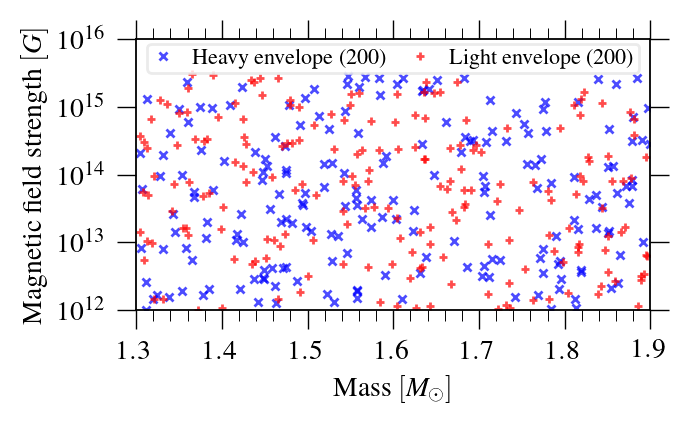

In [30]:

def plot_simulation_parameters(save_path=None):
    # plt.figure()
    plt.subplots(1, 1, constrained_layout=True)
    H = simparams["env"] == "H"
    L = simparams["env"] == "L"
    if not (H | L).all():
        raise RuntimeError("Some simulations have unknown envelope type.")
    masks = [H, L]
    names = ["Heavy envelope", "Light envelope"]
    colors = ["b", "r"]
    markers = ["x", "+"]
    xmin = min(1.3, simparams["M"].min())
    xmax = max(1.9, simparams["M"].max())
    ymin = min(1e12, simparams["B0"].min())
    ymax = max(1e16, simparams["B0"].max())
    yticks = 10.0**np.arange(round(np.log10(ymin)), round(np.log10(ymax)) + 1)
    for mask, name, color, marker in zip(masks, names, colors, markers):
        label = f"{name} ({sum(mask)})"
        subset = simparams[mask]
        x, y = subset["M"], subset["B0"]
        plt.plot(x, y,
                 marker=marker, markersize=3, linestyle="None",
                 color=color, alpha=0.7, label=label)
    plt.xlabel(r"Mass $[M_\odot]$")
    plt.ylabel(r"Magnetic field strength $[G]$")
    plt.yscale("log")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend(ncol=2, loc="upper center")
    plt.yticks(yticks)
    save_figure(save_path)
    plt.show()


plot_simulation_parameters(
    save_path=os.path.join(FIGURES_PATH, "simulation_parameters.pdf"))

# 1.3. Join the parameters and the simulation data

In [31]:
def consistency_check():
    """Check consistency between simulation parameters and data."""
    data_indices = set(csv_data.keys())
    table_indices = set(simparams.index)
    print("Checking for consistency between simulation parameters and data...")
    if data_indices == table_indices:
        print("    PASSED")
    else:
        print("    FAILED")
        miss_dat = table_indices - data_indices
        miss_tab = data_indices - table_indices
        if miss_dat:
            print(f"    Simulations in parameters but not in data: {miss_dat}")
        if miss_tab:
            print(f"    Simulations in data but not in parameters: {miss_tab}")


def join_params_and_data():
    """Join simulation parameters with CSV data."""
    joined_data = None
    data_indices = set(csv_data.keys())

    for index in tqdm(data_indices, desc="Joining parameters and data"):
        data = csv_data[index].copy()
        params = simparams.loc[index]
        for param_name, param_value in params.items():
            data[param_name] = param_value
        data.index = [index] * len(data)
        joined_data = pd.concat([joined_data, data], ignore_index=False)

    # Convert columns to log scale if necessary, and rename columns

    # ...remove columns with non-positive time
    joined_data = joined_data[joined_data["t"] > 0]
    # ...now convert to log scale and rename columns
    for col in COLUMNS_IN_LOG:
        if col not in joined_data.columns:
            raise ValueError(f"Column '{col}' not found in joined data.")
        joined_data[col] = np.log10(joined_data[col])
        joined_data.rename(columns={col: "log" + col}, inplace=True)

    return joined_data


def preprocess_data():
    """Join simulation parameters with CSV data, and make one-hot encoding."""
    consistency_check()
    joined_data = join_params_and_data()
    joined_data = make_onehot(joined_data, categorical_cols=["env"])
    return joined_data


full_data = preprocess_data()
full_data

Checking for consistency between simulation parameters and data...
    PASSED


Joining parameters and data:   0%|          | 0/400 [00:00<?, ?it/s]

,logt,logB,logL,logP,logPdot,M,logB0,env=H,env=L
0,0.113943,13.520877,35.128612,-2.128345,-10.017698,1.401,13.521138,0,1
0,0.176091,13.520872,35.116875,-2.095475,-10.050581,1.401,13.521138,0,1
0,0.255273,13.520864,35.101543,-2.053957,-10.092115,1.401,13.521138,0,1
0,0.322219,13.520856,35.088696,-2.019120,-10.126967,1.401,13.521138,0,1
0,0.397940,13.520846,35.074634,-1.979961,-10.166149,1.401,13.521138,0,1
...,...,...,...,...,...,...,...,...,...
399,5.621903,13.685524,32.772965,1.661287,-13.473653,1.642,15.269513,1,0
399,5.701136,13.485707,32.558178,1.661873,-13.873962,1.642,15.269513,1,0
399,5.780245,13.320896,32.349407,1.662167,-14.205338,1.642,15.269513,1,0
399,5.859439,13.165481,32.234811,1.662334,-14.515738,1.642,15.269513,1,0


## 1.4. Separate to training/validation/test/holdout-curve datasets

In [32]:
def good_fraction(fraction):
    """Check if the fraction is between 0.05 and 0.5."""
    return 0.05 <= fraction <= 0.5


def separate_holdout_curves(table, fraction, random_seed=None):
    assert good_fraction(fraction)

    all_indices = list(set(table.index))
    print(f"Found {len(all_indices)} indices.")

    normal_indices, holdout_indices = train_test_split(
        all_indices, test_size=fraction,
        random_state=random_seed, shuffle=True)
    print(f"Separated {len(holdout_indices)} holdout curves (fraction asked: {fraction}) with random seed {random_seed}.")
    print(f"This left {len(normal_indices)} 'normal' curves.")

    normal_table = table[table.index.isin(normal_indices)]
    holdout_table = table[table.index.isin(holdout_indices)]

    print(f"The 'normal' table contains {len(normal_table)} datapoints ({len(normal_table)/len(table)*100:.2f}%)")
    print(f"The 'holdout' table contains {len(holdout_table)} datapoints ({len(holdout_table)/len(table)*100:.2f}%)")

    return normal_table, holdout_table


def separate_train_valid_test(table, valid_fraction, test_fraction, random_seed=None):
    assert (good_fraction(valid_fraction) and
            good_fraction(test_fraction) and
            good_fraction(valid_fraction + test_fraction))

    train, validtest = train_test_split(
        table, test_size=valid_fraction+test_fraction,
        random_state=random_seed, shuffle=True)

    valid, test = train_test_split(
        validtest, test_size=test_fraction / (valid_fraction + test_fraction),
        random_state=random_seed, shuffle=True)

    datasets = (train, valid, test)
    labels = ("training", "validation", "test")
    for dataset, label in zip(datasets, labels):
        print(f"{label} dataset has {len(dataset)} points "
              f"({100*len(dataset)/len(table):.2f}%)")
    return datasets

normal_dataset, holdout_dataset = separate_holdout_curves(
    full_data, fraction=1/6, random_seed=RANDOM_SEED)

train_dataset, valid_dataset, test_dataset = separate_train_valid_test(
    normal_dataset, valid_fraction=1/5, test_fraction=1/5, random_seed=RANDOM_SEED)


Found 400 indices.
Separated 67 holdout curves (fraction asked: 0.16666666666666666) with random seed 31337.
This left 333 'normal' curves.
The 'normal' table contains 24297 datapoints (83.37%)
The 'holdout' table contains 4848 datapoints (16.63%)
training dataset has 14578 points (60.00%)
validation dataset has 4859 points (20.00%)
test dataset has 4860 points (20.00%)


## 1.5 Save the data

In [33]:
os.makedirs(DATASETS_FOLDER, exist_ok=True)

datasets = [full_data, train_dataset, valid_dataset, test_dataset, holdout_dataset]
labels = ["full", "train", "valid", "test", "holdout"]
for dataset, label in zip(datasets, labels):
    print(f"Saving `{label}.csv`...")
    filepath = os.path.join(DATASETS_FOLDER, label + ".csv.gz")
    dataset = dataset.sort_values("logt")
    dataset.to_csv(filepath, index_label="index")

Saving `full.csv`...
Saving `train.csv`...
Saving `valid.csv`...
Saving `test.csv`...
Saving `holdout.csv`...
